# Fase 3: Análisis Exploratorio (EDA)

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType
from pyspark.sql import functions as F

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Create the spark session
spark = SparkSession.builder \
    .appName("Silver") \
    .config("spark.sql.session.timeZone", "UTC") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 05:42:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/25 05:42:55 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/25 05:42:55 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [3]:
df = spark.read.parquet("/app/data/silver/spotify_clean.parquet")

## Analisis 1: Patrones Temporales

In [4]:
# Count of artists and songs
artists_count = df.select("master_metadata_album_artist_name").distinct().count()
songs_count = df.select("spotify_track_uri").distinct().count()

print(f"Total de artistas unicos escuchados: {artists_count:,}")
print(f"Total de canciones unicas escuchadas: {songs_count:,}")

# Most listened artist
top_artist = df.filter(F.col("master_metadata_album_artist_name") != "Unknown Artist") \
    .groupBy("master_metadata_album_artist_name") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .first()

print(f"Artista más escuchado: {top_artist['master_metadata_album_artist_name']} ({top_artist['count']:,} reproducciones)")

# Most listened song
top_song = df.filter(F.col("master_metadata_track_name") != "Unknown Track") \
    .groupBy("master_metadata_track_name", "master_metadata_album_artist_name") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .first()

print(f"Canción más escuchada: '{top_song['master_metadata_track_name']}' de {top_song['master_metadata_album_artist_name']} ({top_song['count']:,} reproducciones)")

Total de artistas unicos escuchados: 9,417
Total de canciones unicas escuchadas: 32,896
Artista más escuchado: Imagine Dragons (8,470 reproducciones)
Canción más escuchada: 'Believer' de Imagine Dragons (390 reproducciones)


### Distribución de escucha por hora del día

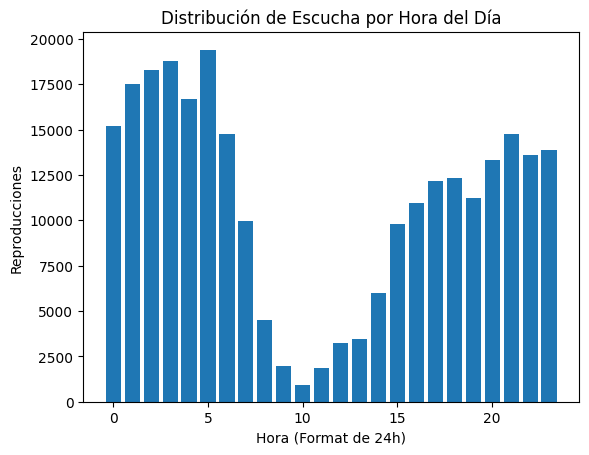

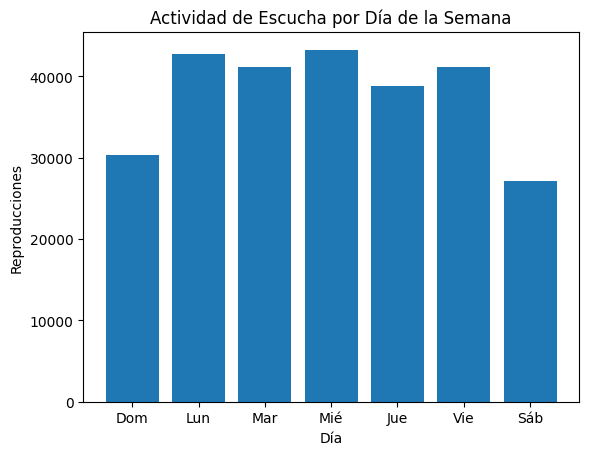

In [5]:
df_hour = df.groupBy("hour").count().orderBy("hour").toPandas()

day_labels = {1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie", 7: "Sáb"}
df_day = df.groupBy("day_of_week").count().orderBy("day_of_week").toPandas()
df_day["day_name"] = df_day["day_of_week"].map(day_labels)

plt.figure()
plt.bar(df_hour["hour"], df_hour["count"])
plt.title("Distribución de Escucha por Hora del Día")
plt.xlabel("Hora (Format de 24h)")
plt.ylabel("Reproducciones")
plt.show()

plt.figure()
plt.bar(df_day["day_name"], df_day["count"])
plt.title("Actividad de Escucha por Día de la Semana")
plt.xlabel("Día")
plt.ylabel("Reproducciones")
plt.show()

### Tendencia mensual de consumo

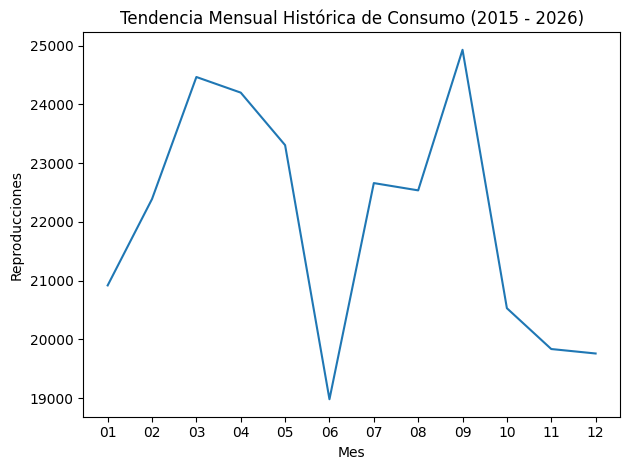

In [6]:
df_trend = df.groupBy("month").count().orderBy("month").toPandas()

df_trend["month_axis"] = df_trend["month"].astype(str).str.zfill(2)

plt.plot(df_trend["month_axis"], df_trend["count"])
plt.title("Tendencia Mensual Histórica de Consumo (2015 - 2026)")
plt.xlabel("Mes")
plt.ylabel("Reproducciones")
plt.tight_layout()
plt.show()

### Mapa de calor día x hora

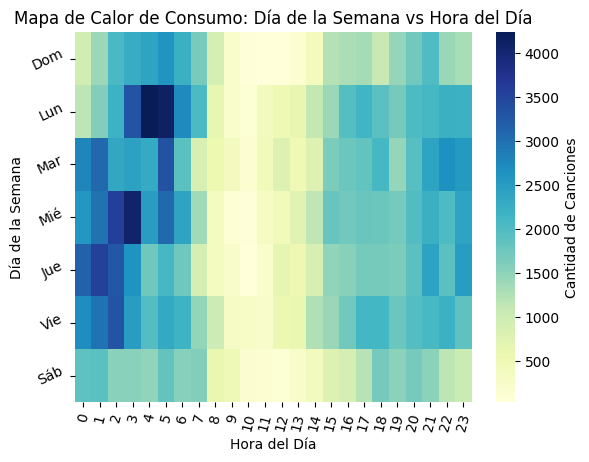

--- Identificacion de hora pico ---
Tu momento pico de escucha es los: Lun a las 4:00 hrs con 4,237 reproducciones acumuladas.


In [10]:
df_pivot = df.groupBy("day_of_week").pivot("hour").count().orderBy("day_of_week").toPandas()

df_pivot = df_pivot.set_index("day_of_week")
df_pivot.index = df_pivot.index.map(day_labels)
df_pivot = df_pivot.fillna(0)

sns.heatmap(df_pivot, cmap="YlGnBu", annot=False, fmt="g", cbar_kws={'label': 'Cantidad de Canciones'})
plt.title("Mapa de Calor de Consumo: Día de la Semana vs Hora del Día")
plt.xlabel("Hora del Día")
plt.xticks(rotation=75)
plt.ylabel("Día de la Semana")
plt.yticks(rotation=25)
plt.show()

df_peak = df.groupBy("day_of_week", "hour").count().orderBy(F.col("count").desc()).first()
peak_day = day_labels[df_peak["day_of_week"]]

print("--- Identificacion de hora pico ---")
print(f"Tu momento pico de escucha es los: {peak_day} a las {df_peak['hour']}:00 hrs con {df_peak['count']:,} reproducciones acumuladas.")

### Top 20 artistas y canciones más reproducidas

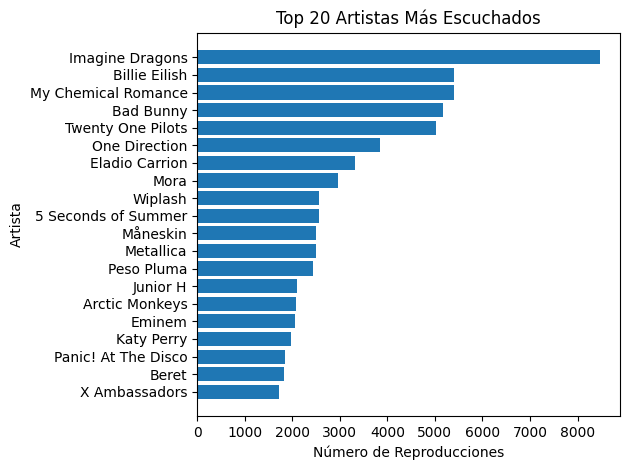

In [11]:
# Top artists
df_top_artists = df.filter(F.col("master_metadata_album_artist_name") != "Unknown Artist") \
    .groupBy("master_metadata_album_artist_name") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .limit(20) \
    .toPandas()

plt.barh(df_top_artists["master_metadata_album_artist_name"], df_top_artists["count"])
plt.gca().invert_yaxis()
plt.title("Top 20 Artistas Más Escuchados")
plt.xlabel("Número de Reproducciones")
plt.ylabel("Artista")
plt.tight_layout()
plt.show()

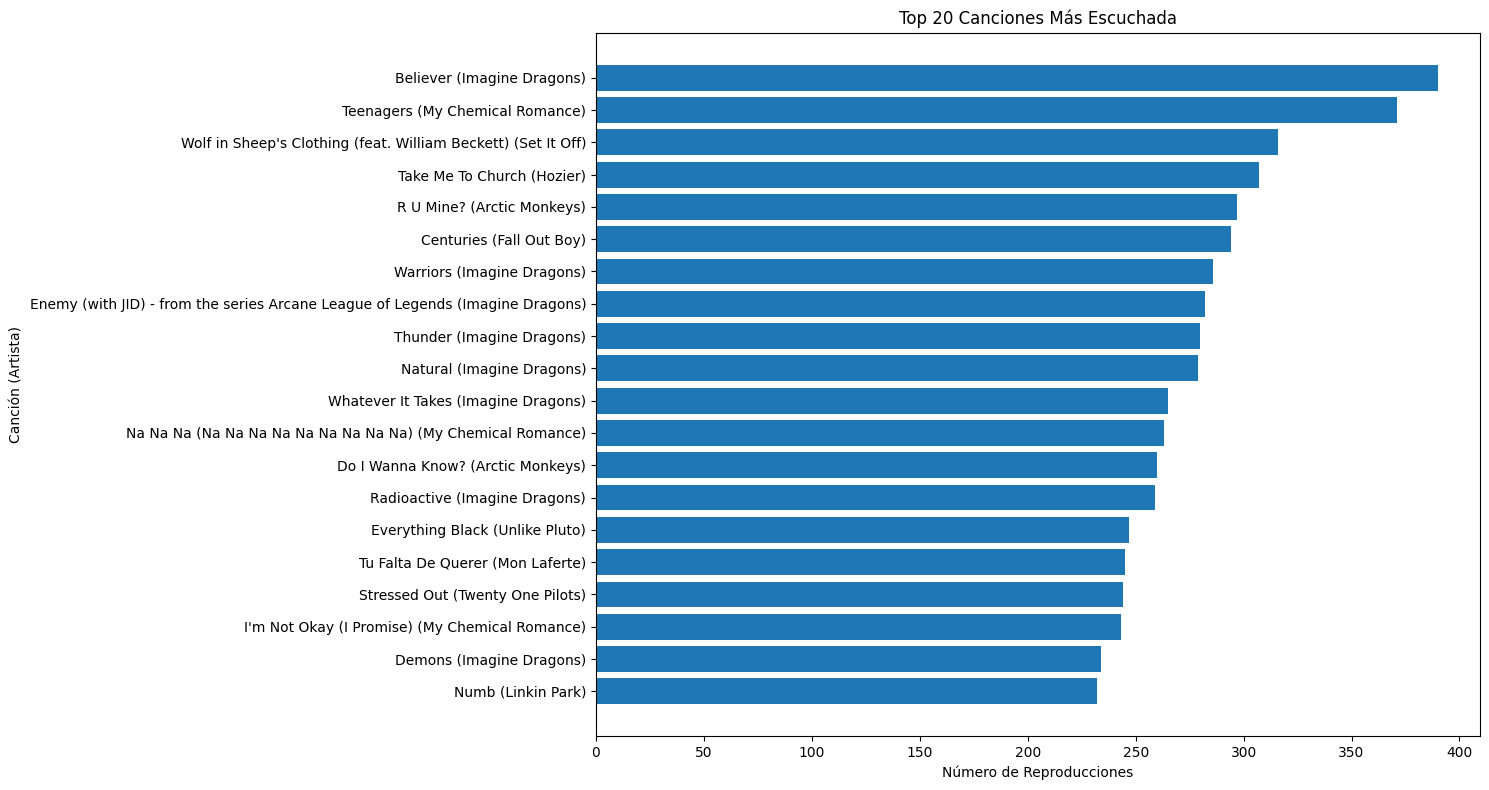

In [12]:
# Top songs
df_top_songs = df.filter(F.col("master_metadata_track_name") != "Unknown Track") \
    .groupBy("master_metadata_track_name", "master_metadata_album_artist_name") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .limit(20) \
    .toPandas()

df_top_songs["song_artist"] = df_top_songs["master_metadata_track_name"] + " (" + df_top_songs["master_metadata_album_artist_name"] + ")"

plt.figure(figsize=(15, 8))
plt.barh(df_top_songs["song_artist"], df_top_songs["count"])
plt.gca().invert_yaxis()
plt.title("Top 20 Canciones Más Escuchada")
plt.xlabel("Número de Reproducciones")
plt.ylabel("Canción (Artista)")
plt.tight_layout()
plt.show()

###  Tasa de completación vs skip

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


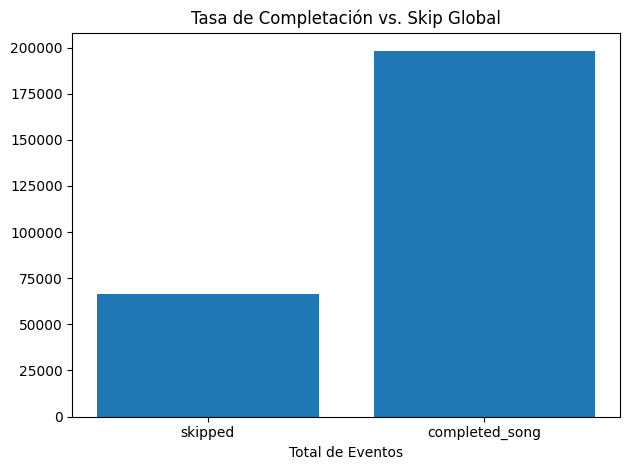

In [13]:
df_skip = df.groupBy("skipped").count().toPandas()

df_skip["state"] = df_skip["skipped"].map({True: "skipped", False: "completed_song"})

plt.bar(df_skip["state"], df_skip["count"])
plt.title("Tasa de Completación vs. Skip Global")
plt.xlabel("Total de Eventos")
plt.ylabel("")
plt.tight_layout()
plt.show()